## STATIONARITY TESTS  ##

- Mục tiêu: xác định d, D cho SARIMA/ARIMAX                 
- Tests   : ADF · KPSS · ACF/PACF

## 0. Import & Setup

In [1]:
# ── SETUP ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima.utils import ndiffs, nsdiffs
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── STYLE ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL  = "#1D9E75"
BLUE  = "#378ADD"
CORAL = "#D85A30"
AMBER = "#BA7517"
RED   = "#E24B4A"
GRAY  = "#888780"
 
import os
os.makedirs("../outputs", exist_ok=True)

## 1. Load Data

chỉ dùng TRAIN để test stationarity

In [3]:
# ── LOAD PROCESSED DATA ───────────────────────────────────────────────
df = pd.read_csv("../data/processed_data.csv",
                 index_col="date", parse_dates=True)
df.index.freq = "MS"
 
train = df[df.index <= "2019-12-01"].copy()
s     = train["log_arrivals"]        # series chính
st    = train["log_search_trends"]   # exogenous
 
print(f"  Train set: {len(train)} obs  ({train.index[0].strftime('%m/%Y')} → {train.index[-1].strftime('%m/%Y')})")
print(f"  Series   : log_arrivals (log1p transform từ Bước 2)")
print(f"\n  NOTE: Stationarity test trên TRAIN ONLY")
print(f"  → tránh data leakage từ COVID period vào test selection")

  Train set: 120 obs  (01/2010 → 12/2019)
  Series   : log_arrivals (log1p transform từ Bước 2)

  NOTE: Stationarity test trên TRAIN ONLY
  → tránh data leakage từ COVID period vào test selection


## 2. VISUAL INSPECTION — 4 dạng biến thể của series

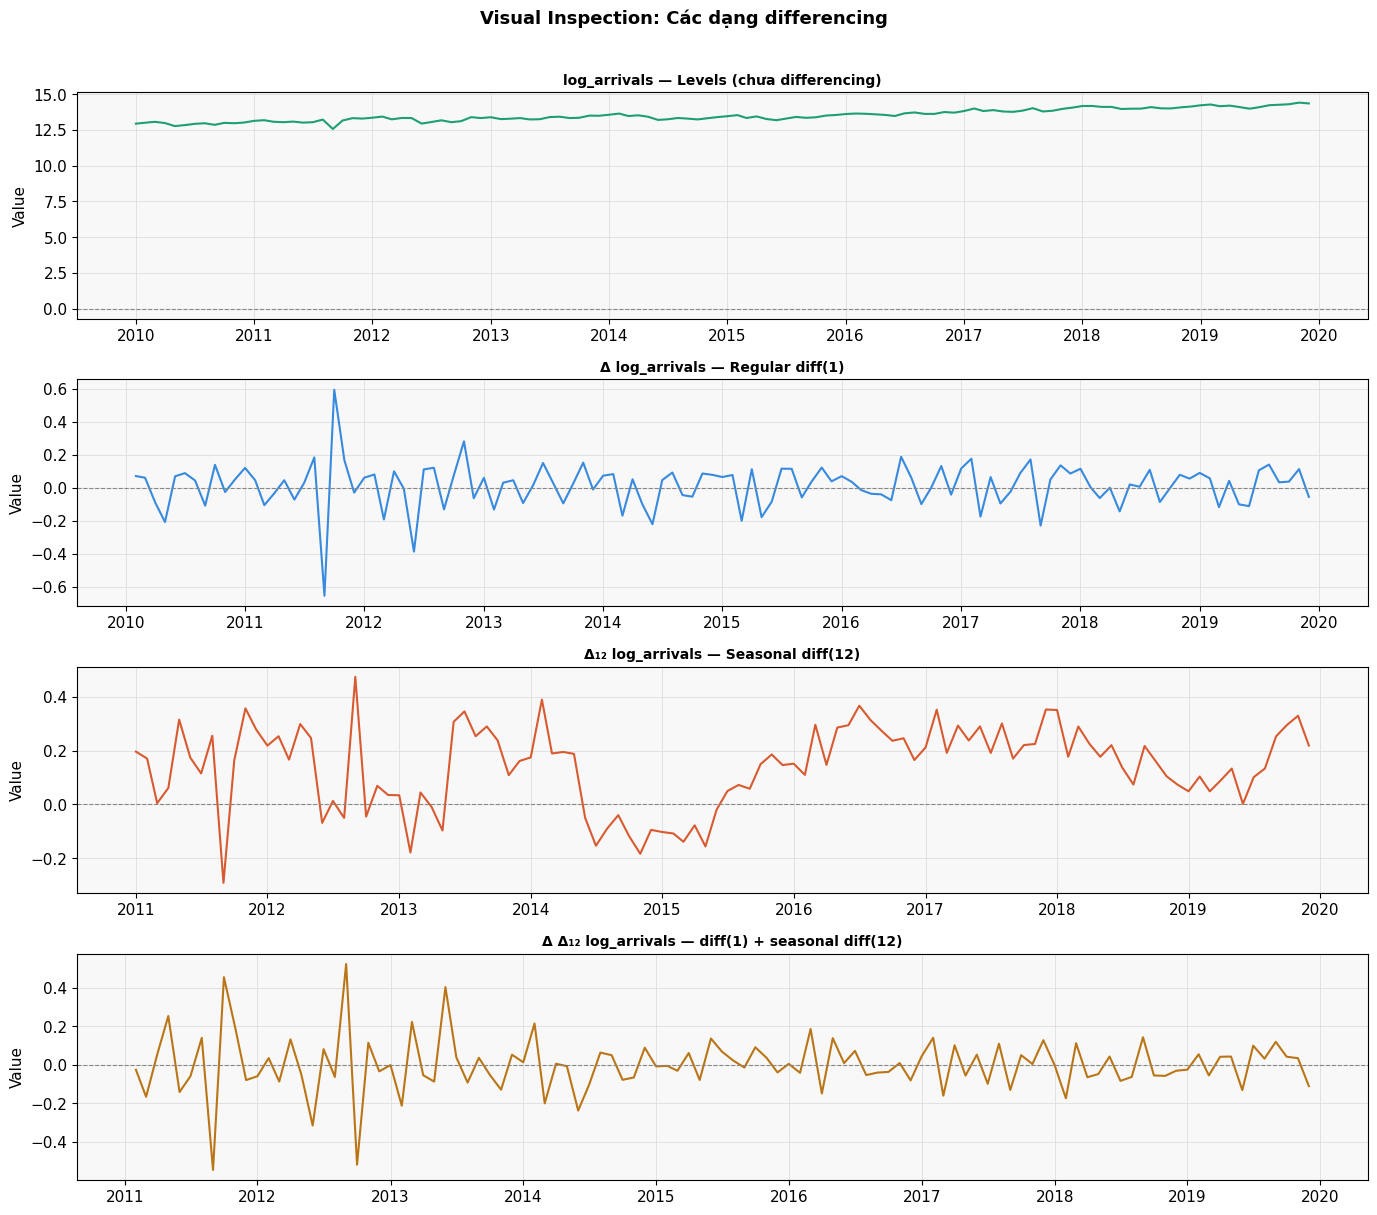

In [4]:
# ── VISUAL INSPECTION: DIFFERENCING ──────────────────────────────────
s_d1   = s.diff().dropna()           # diff bậc 1
s_D1   = s.diff(12).dropna()         # seasonal diff
s_d1D1 = s.diff().diff(12).dropna()  # cả hai
 
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
specs = [
    (s,      TEAL,  "log_arrivals — Levels (chưa differencing)"),
    (s_d1,   BLUE,  "Δ log_arrivals — Regular diff(1)"),
    (s_D1,   CORAL, "Δ₁₂ log_arrivals — Seasonal diff(12)"),
    (s_d1D1, AMBER, "Δ Δ₁₂ log_arrivals — diff(1) + seasonal diff(12)"),
]
for ax, (series, color, title) in zip(axes, specs):
    ax.plot(series.index, series.values, color=color, lw=1.5)
    ax.axhline(0, color=GRAY, lw=0.8, ls="--")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylabel("Value")
 
plt.suptitle("Visual Inspection: Các dạng differencing",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/step3_differencing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

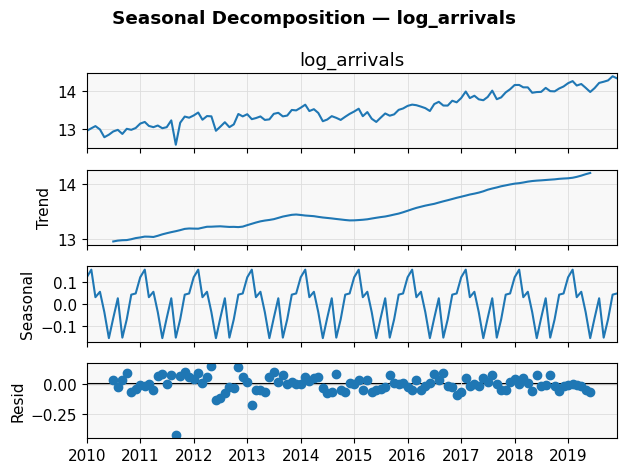

In [5]:
# ── Seasonal Decomposition ─────────────────────────
decomp = seasonal_decompose(s, model="additive", period=12)

decomp.plot()
plt.suptitle(
    "Seasonal Decomposition — log_arrivals",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

## 3. ADF TEST (Augmented Dickey-Fuller)

H0: chuỗi có unit root (KHÔNG dừng)   
Reject H0 khi p < 0.05 → chuỗi Dừng

In [6]:
# ── ADF TEST: DIFFERENCING OPTIONS ─────────────────────────────────
print("=" * 62)
print("  ADF TEST — log_arrivals (train set)")
print("  H0: có unit root (không dừng) | Reject H0 nếu p < 0.05")
print("=" * 62)
 
adf_cases = [
    ("Levels",                 s),
    ("diff(1)",                s_d1),
    ("seasonal diff(12)",      s_D1),
    ("diff(1) + diff(12)",     s_d1D1),
]
 
adf_results = {}
for label, series in adf_cases:
    stat, p, lags, _, crit, _ = adfuller(series, autolag="AIC")
    conclusion = "✓ DỪNG" if p < 0.05 else "✗ CHƯA DỪNG"
    adf_results[label] = {"stat": stat, "p": p, "lags": lags,
                          "crit_5": crit["5%"], "conclusion": conclusion}
    print(f"\n  [{label}]")
    print(f"    ADF stat   : {stat:8.4f}  (critical 5%: {crit['5%']:.4f})")
    print(f"    p-value    : {p:.4f}")
    print(f"    Lags used  : {lags}")
    print(f"    Kết luận   : {conclusion}")
 
print()

  ADF TEST — log_arrivals (train set)
  H0: có unit root (không dừng) | Reject H0 nếu p < 0.05

  [Levels]
    ADF stat   :   0.4956  (critical 5%: -2.8892)
    p-value    : 0.9847
    Lags used  : 13
    Kết luận   : ✗ CHƯA DỪNG

  [diff(1)]
    ADF stat   :  -3.0963  (critical 5%: -2.8892)
    p-value    : 0.0268
    Lags used  : 12
    Kết luận   : ✓ DỪNG

  [seasonal diff(12)]
    ADF stat   :  -3.2204  (critical 5%: -2.8925)
    p-value    : 0.0188
    Lags used  : 12
    Kết luận   : ✓ DỪNG

  [diff(1) + diff(12)]
    ADF stat   :  -3.6053  (critical 5%: -2.8932)
    p-value    : 0.0057
    Lags used  : 13
    Kết luận   : ✓ DỪNG



In [7]:
# ── AUTO SELECTION: PMDARIMA NDFFS/NSDIFFS ─────────────────────────────
print("\n  Nhận xét (tự động):")
for k, v in adf_results.items():
    print(f"  → {k:20s}: p={v['p']:.4f} → {v['conclusion']}")


  Nhận xét (tự động):
  → Levels              : p=0.9847 → ✗ CHƯA DỪNG
  → diff(1)             : p=0.0268 → ✓ DỪNG
  → seasonal diff(12)   : p=0.0188 → ✓ DỪNG
  → diff(1) + diff(12)  : p=0.0057 → ✓ DỪNG


In [8]:
# ── ADF — log_search_trends ────────────────────────
print("\nADF — log_search_trends")

adf_st = adfuller(st, autolag="AIC")

print(f"ADF Statistic: {adf_st[0]:.4f}")
print(f"p-value      : {adf_st[1]:.4f}")

if adf_st[1] < 0.05:
    print("→ Stationary")
else:
    print("→ Non-stationary")


ADF — log_search_trends
ADF Statistic: -3.0091
p-value      : 0.0341
→ Stationary


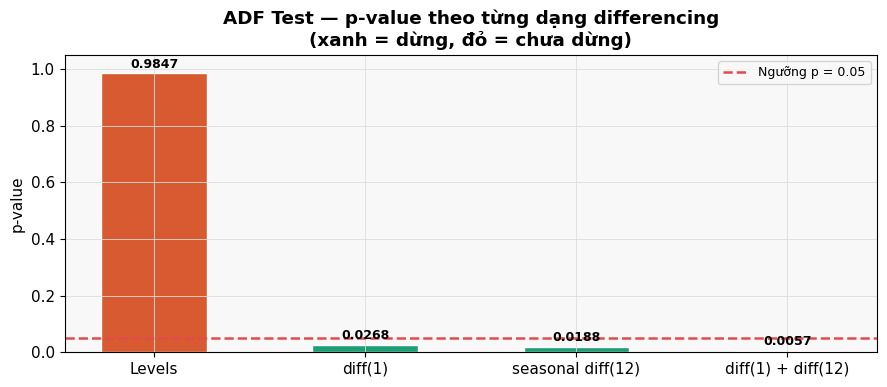

In [9]:
# ── ADF plot ─────────────────────────────────────────
labels_plot = list(adf_results.keys())
p_vals = [adf_results[l]["p"] for l in labels_plot]
colors_bar = [TEAL if p < 0.05 else CORAL for p in p_vals]
 
plt.figure(figsize=(9, 4))
bars = plt.bar(labels_plot, p_vals, color=colors_bar, width=0.5, edgecolor="white")
plt.axhline(0.05, color=RED, lw=1.8, ls="--", label="Ngưỡng p = 0.05")
plt.title("ADF Test — p-value theo từng dạng differencing\n(xanh = dừng, đỏ = chưa dừng)",
          fontweight="bold")
plt.ylabel("p-value")
plt.ylim(0, 1.05)
plt.legend(fontsize=9)
for bar, p in zip(bars, p_vals):
    plt.text(bar.get_x() + bar.get_width()/2, p + 0.02,
             f"{p:.4f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step3_adf_pvalues.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. KPSS TEST

H0: chuỗi DỪng (ngược với ADF)       
Reject H0 khi p < 0.05 → chuỗi KHÔNG dừng     
→ Dùng kết hợp ADF + KPSS để kết luận chắc chắn hơn

In [10]:
# ── KPSS TEST: DIFFERENCING OPTIONS ─────────────────────────────────
print("=" * 62)
print("  KPSS TEST — log_arrivals (train set)")
print("  H0: chuỗi dừng | Reject H0 nếu p < 0.05")
print("=" * 62)
 
kpss_cases = [
    ("Levels", s),
    ("diff(1)", s_d1),
    ("seasonal diff(12)", s_D1),
]
 
for label, series in kpss_cases:
    stat, p, lags, crit = kpss(series, regression="ct", nlags="auto")
    conclusion = "✗ KHÔNG DỪNG (reject H0)" if p < 0.05 else "✓ DỪNG (fail to reject)"
    print(f"\n  [{label}]")
    print(f"    KPSS stat  : {stat:.4f}  (critical 5%: {crit['5%']:.4f})")
    print(f"    p-approx   : {p:.4f}")
    print(f"    Kết luận   : {conclusion}")

  KPSS TEST — log_arrivals (train set)
  H0: chuỗi dừng | Reject H0 nếu p < 0.05

  [Levels]
    KPSS stat  : 0.2573  (critical 5%: 0.1460)
    p-approx   : 0.0100
    Kết luận   : ✗ KHÔNG DỪNG (reject H0)

  [diff(1)]
    KPSS stat  : 0.1516  (critical 5%: 0.1460)
    p-approx   : 0.0454
    Kết luận   : ✗ KHÔNG DỪNG (reject H0)

  [seasonal diff(12)]
    KPSS stat  : 0.1113  (critical 5%: 0.1460)
    p-approx   : 0.1000
    Kết luận   : ✓ DỪNG (fail to reject)


## 5. ACF / PACF — phân tích pattern để chọn p, q, P, Q

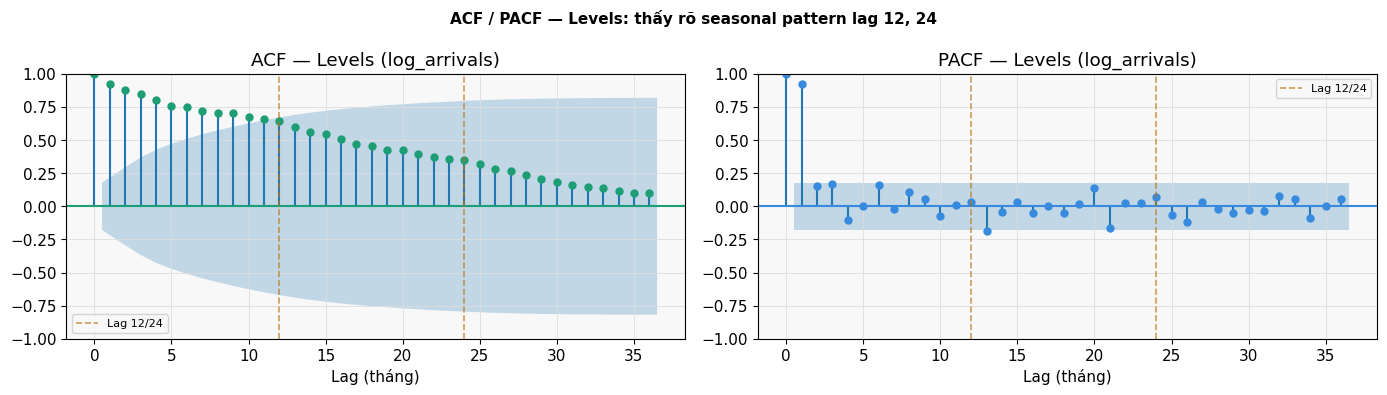

In [11]:
# ── ACF/PACF levels ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s,  lags=36, ax=axes[0], color=TEAL, alpha=0.05,
         title="ACF — Levels (log_arrivals)")
plot_pacf(s, lags=36, ax=axes[1], color=BLUE, alpha=0.05,
          title="PACF — Levels (log_arrivals)", method="ywm")
for ax in axes:
    ax.axvline(12, color=AMBER, lw=1.2, ls="--", alpha=0.7, label="Lag 12/24")
    ax.axvline(24, color=AMBER, lw=1.2, ls="--", alpha=0.7)
    ax.set_xlabel("Lag (tháng)")
    ax.legend(fontsize=8)
plt.suptitle("ACF / PACF — Levels: thấy rõ seasonal pattern lag 12, 24",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step3_acf_pacf_levels.png", dpi=150, bbox_inches="tight")
plt.show()

Nhận xét:  
→ ACF giảm chậm → xác nhận chuỗi chưa dừng (non-stationary)  
→ Seasonal spikes tại lag 12 vẫn rõ → seasonal pattern tồn tại  
→ PACF không cắt hoàn toàn → gợi ý có cả AR và MA component  

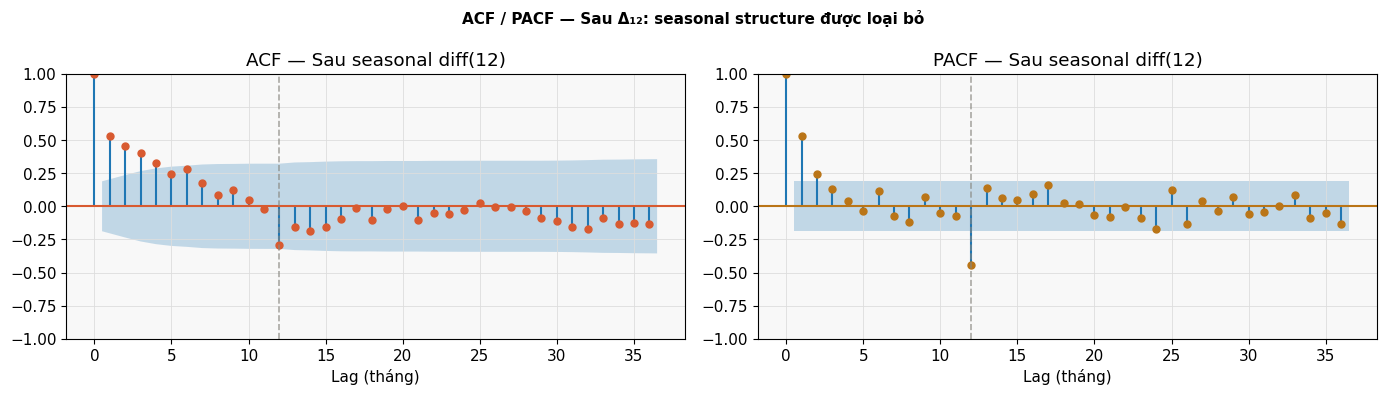

In [12]:
# ── ACF/PACF sau seasonal diff(12) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s_D1,  lags=36, ax=axes[0], color=CORAL, alpha=0.05,
         title="ACF — Sau seasonal diff(12)")
plot_pacf(s_D1, lags=36, ax=axes[1], color=AMBER, alpha=0.05,
          title="PACF — Sau seasonal diff(12)", method="ywm")
for ax in axes:
    ax.axvline(12, color=GRAY, lw=1.2, ls="--", alpha=0.7)
    ax.set_xlabel("Lag (tháng)")
plt.suptitle("ACF / PACF — Sau Δ₁₂: seasonal structure được loại bỏ",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step3_acf_pacf_seasonal_diff.png", dpi=150, bbox_inches="tight")
plt.show()

Sau seasonal diff:  
→ ACF decay nhanh hơn → stationarity được cải thiện rõ rệt  
→ Seasonal spikes giảm mạnh nhưng vẫn còn dấu hiệu nhẹ  
→ Cho thấy seasonal differencing giúp giảm nhưng chưa loại bỏ hoàn toàn seasonality  

## 6. AUTO SELECTION — ndiffs / nsdiffs (pmdarima)

In [13]:
# ── AUTO SELECTION: PMDARIMA NDFFS/NSDIFFS ─────────────────────────────
print("=" * 62)
print("  AUTO SELECTION — pmdarima: ndiffs / nsdiffs")
print("=" * 62)
 
d_adf  = ndiffs(s, test="adf")
d_kpss = ndiffs(s, test="kpss")
d_pp   = ndiffs(s, test="pp")
D_ocsb = nsdiffs(s, m=12, test="ocsb")
D_ch   = nsdiffs(s, m=12, test="ch")
 
print(f"\n  ndiffs (ADF) : d = {d_adf}")
print(f"  ndiffs (KPSS): d = {d_kpss}")
print(f"  ndiffs (PP)  : d = {d_pp}")
print(f"\n  nsdiffs (OCSB): D = {D_ocsb}")
print(f"  nsdiffs (CH)  : D = {D_ch}")


  AUTO SELECTION — pmdarima: ndiffs / nsdiffs

  ndiffs (ADF) : d = 0
  ndiffs (KPSS): d = 1
  ndiffs (PP)  : d = 0

  nsdiffs (OCSB): D = 0
  nsdiffs (CH)  : D = 0


#### Phân tích:
→ nsdiffs đề xuất D = 0 (dựa trên statistical test)   
→ Tuy nhiên ACF vẫn cho thấy seasonal pattern (lag 12)  

→ Do đó:  
   - Kết hợp domain knowledge + visual inspection  
   - Quyết định sử dụng D = 1 để đảm bảo loại bỏ seasonality  
  
⇒ Chọn D = 1 (conservative & robust choice)

## 7. KẾT LUẬN — d, D cho SARIMA/ARIMAX

1. Chuỗi gốc KHÔNG dừng:   
   → Có trend tăng mạnh   
   → Có seasonal pattern rõ (lag 12)  

2. Differencing:  
   → diff(1): giảm trend nhưng chưa chắc đã đủ dừng    
   → seasonal differencing (lag 12) giúp cải thiện stationarity đáng kể   
   → Kết hợp với differencing bậc 1 cho kết quả ổn định nhất
 
   → Các test (ADF + KPSS) và ACF/PACF đều ủng hộ:  
   d = 1, D = 1  

3. Statistical tests:  
   → ADF: seasonal diff(12) cho p-value rất nhỏ → stationary  
   → KPSS: không bác bỏ stationarity sau differencing  

4. Quyết định:  
   → d = 0 hoặc 1 (chưa hoàn toàn rõ từ tests)  
   → D = 1 (seasonality rõ ràng + ACF + ADF confirm)  

5. Lưu ý về nsdiffs:  
   → nsdiffs có thể underestimate seasonal component  
   → ACF + decomposition cho evidence mạnh hơn  
⇒ do đó fix D = 1 trong modeling   

6. Strategy:  
   → để auto_arima chọn d tối ưu  
   → fix D = 1 hoặc thử cả D = {0,1}  

⇒ SARIMA candidates:  
   (p,d,q)(P,1,Q,12) với d ∈ {0,1}  

  

#### Note:
Việc không loại bỏ missing values ở bước feature engineering giúp giữ nguyên cấu trúc chuỗi thời gian,
từ đó kết quả stationarity tests phản ánh chính xác hơn đặc tính của dữ liệu gốc.

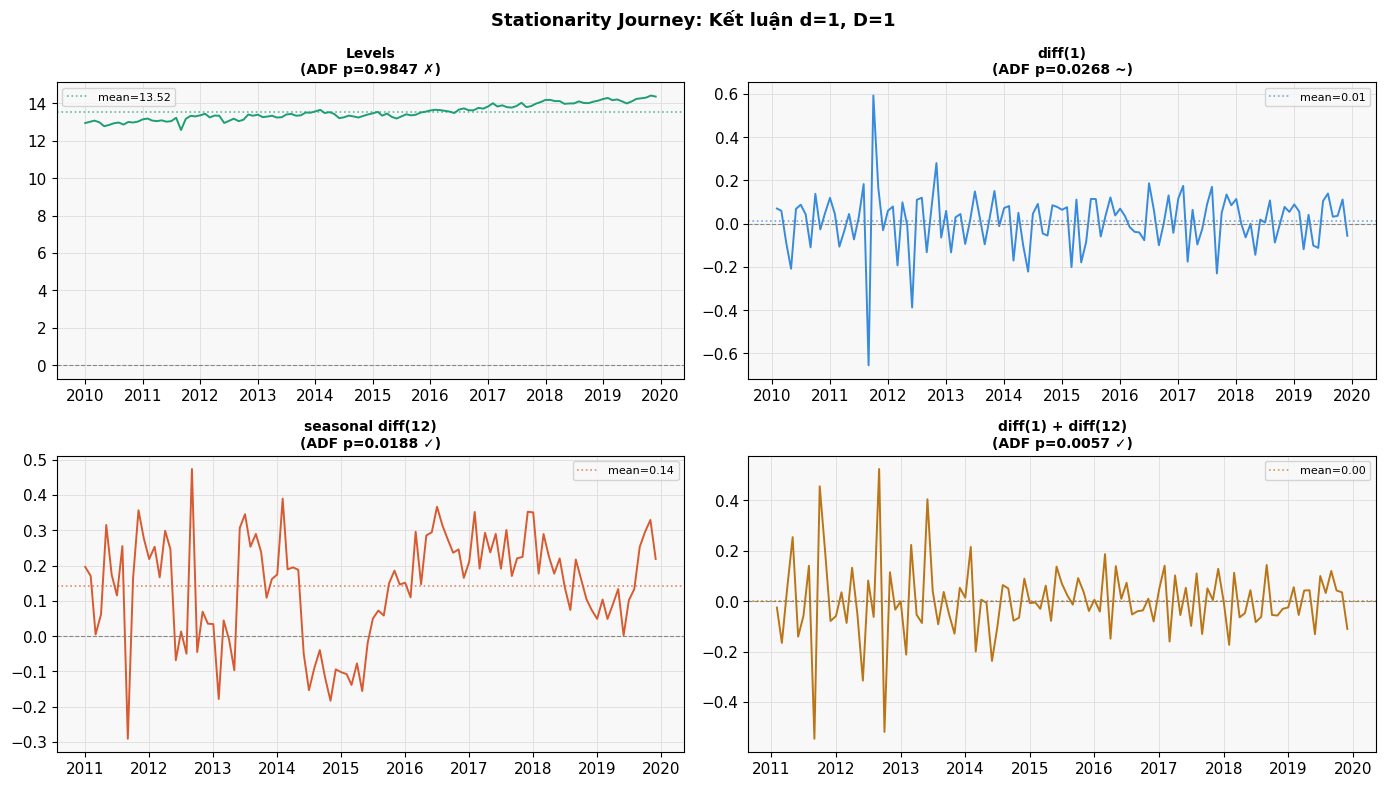


  [✓] Đã lưu tất cả outputs


In [14]:
# ── Summary plot — stationarity journey ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    (s,      TEAL,  f"Levels\n(ADF p={adf_results['Levels']['p']:.4f} ✗)"),
    (s_d1,   BLUE,  f"diff(1)\n(ADF p={adf_results['diff(1)']['p']:.4f} ~)"),
    (s_D1,   CORAL, f"seasonal diff(12)\n(ADF p={adf_results['seasonal diff(12)']['p']:.4f} ✓)"),
    (s_d1D1, AMBER, f"diff(1) + diff(12)\n(ADF p={adf_results['diff(1) + diff(12)']['p']:.4f} ✓)"),
]
for ax, (series, color, title) in zip(axes.flat, pairs):
    ax.plot(series.index, series.values, color=color, lw=1.4)
    ax.axhline(0, color=GRAY, lw=0.8, ls="--")
    ax.set_title(title, fontweight="bold", fontsize=10)
    mean_val = series.mean()
    ax.axhline(mean_val, color=color, lw=1.2, ls=":", alpha=0.7,
               label=f"mean={mean_val:.2f}")
    ax.legend(fontsize=8)
 
plt.suptitle("Stationarity Journey: Kết luận d=1, D=1",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step3_summary.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n  [✓] Đã lưu tất cả outputs")
